In [1]:
%load_ext autoreload
%autoreload 2

import data_formater69 as df
import calib69 as calib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

c:\GAMS\51\GMSPython\Lib\site-packages\dreamtools\gams_pandas\gdx.py:22: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  workspace = gams.GamsWorkspace()
c:\GAMS\51\GMSPython\Lib\site-packages\gams\core\numpy\gams2numpy.py:70: UserWarning: The GAMS version (51.4.0) differs from the API version (51.3.0).
  ws = GamsWorkspace(system_directory=system_directory)


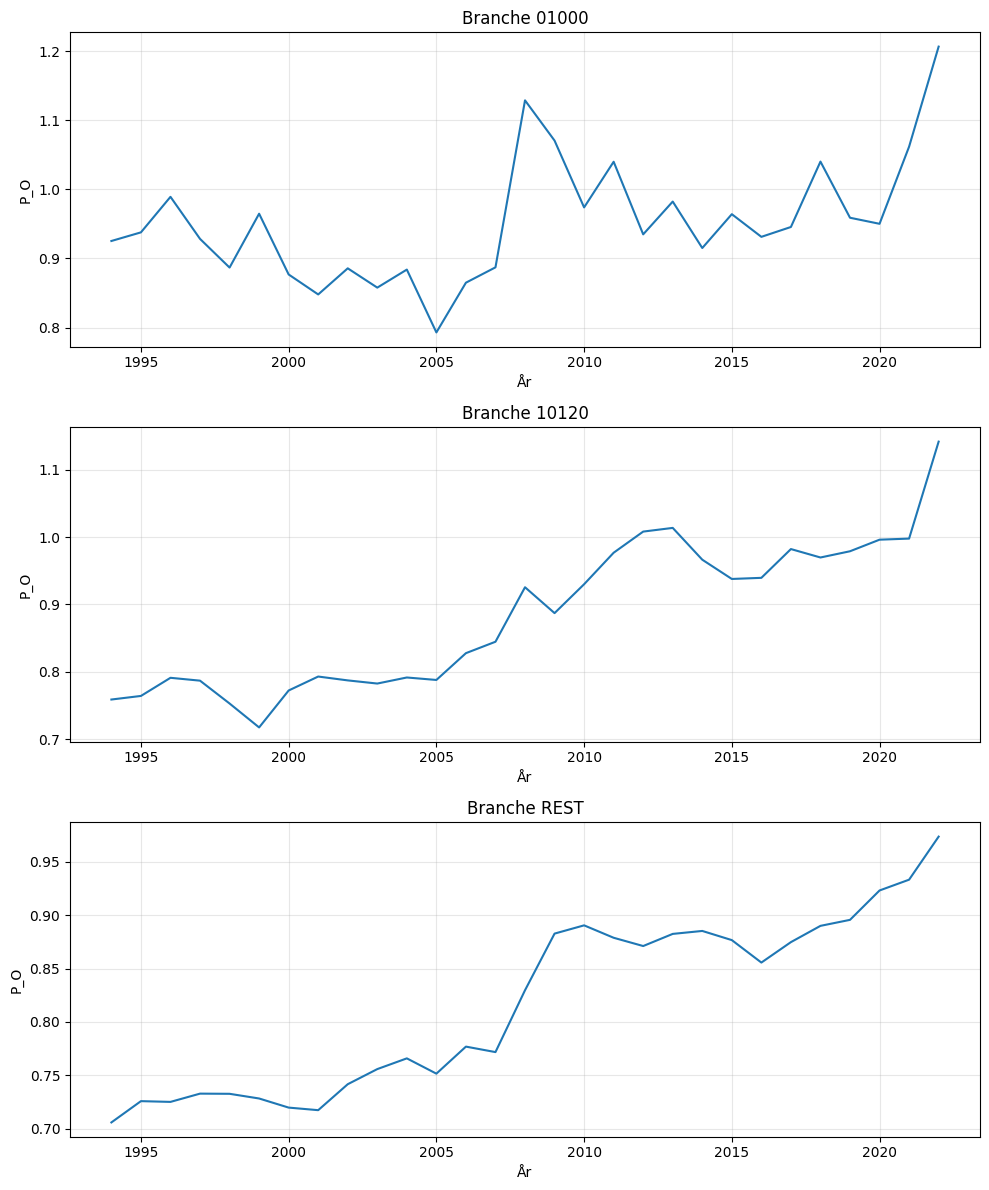

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(calib.P_O.index.get_level_values('ANVENDELSE').unique()), 1, figsize=(10, 12))

for ax, branche in zip(axes, calib.P_O.index.get_level_values('ANVENDELSE').unique()):
    d = calib.P_O.loc[branche].loc[1994:2022]
    ax.plot(d.index, d.values)
    ax.set_title(f"Branche {branche}")
    ax.set_xlabel("År")
    ax.set_ylabel("P_O")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Udtræk af variable

In [3]:
# 1) Variabler du vil udtrække
variables_to_export = [
    "Y", "Mtot", "KL", "JKL", "K", "L",
    "P", "w", "P_K", "P_KL", "P_JKL", "P_O",
    "mu_Y_Mtot", "mu_Y_KL", "mu_Y_JKL",
    "mu_JKL_J", "mu_JKL_KL",
    "mu_KL_K", "mu_KL_L",
    "markup", "tau_Y",
]

# 2) Eksisterende Excel-fil (i samme mappe som notebook/script)
output_excel = "Dokumentation.xlsx"

def get_var(var_name):
    # Finder variablen i df eller calib
    if hasattr(df, var_name):
        return getattr(df, var_name)
    if hasattr(calib, var_name):
        return getattr(calib, var_name)
    raise KeyError(f"Variabel '{var_name}' findes ikke i df eller calib")


def to_series(obj):
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, pd.DataFrame):
        for col in ["Xt", "Pt", "INDHOLD"]:
            if col in obj.columns:
                return obj[col]
        if len(obj.columns) == 1:
            return obj.iloc[:, 0]
        raise ValueError(
            f"DataFrame for variablen har flere kolonner ({list(obj.columns)}). "
            "Vælg én kolonne manuelt."
        )
    raise TypeError(f"Ukendt datatype: {type(obj)}")


def pivot_years(s):
    # Pivot: TID (år) ud i kolonner
    if not isinstance(s.index, pd.MultiIndex) or "TID" not in s.index.names:
        raise ValueError("Forventer MultiIndex med niveauet 'TID'")
    wide = s.unstack("TID")

    # sorter årskolonner
    try:
        wide = wide.reindex(sorted(wide.columns, key=lambda x: int(x)), axis=1)
    except Exception:
        wide = wide.sort_index(axis=1)

    return wide


# 3) Skriv til eksisterende Excel-fil, ét ark pr. variabel
with pd.ExcelWriter(output_excel, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    for var in variables_to_export:
        raw = get_var(var)
        s = to_series(raw)
        out = pivot_years(s)

        # Excel-arknavn max 31 tegn
        sheet = var[:31]
        out.to_excel(writer, sheet_name=sheet)
        print(f"Eksporteret: {var} -> {sheet}")

Eksporteret: Y -> Y
Eksporteret: Mtot -> Mtot
Eksporteret: KL -> KL
Eksporteret: JKL -> JKL
Eksporteret: K -> K
Eksporteret: L -> L
Eksporteret: P -> P
Eksporteret: w -> w
Eksporteret: P_K -> P_K
Eksporteret: P_KL -> P_KL
Eksporteret: P_JKL -> P_JKL
Eksporteret: P_O -> P_O
Eksporteret: mu_Y_Mtot -> mu_Y_Mtot
Eksporteret: mu_Y_KL -> mu_Y_KL
Eksporteret: mu_Y_JKL -> mu_Y_JKL
Eksporteret: mu_JKL_J -> mu_JKL_J
Eksporteret: mu_JKL_KL -> mu_JKL_KL
Eksporteret: mu_KL_K -> mu_KL_K
Eksporteret: mu_KL_L -> mu_KL_L
Eksporteret: markup -> markup
Eksporteret: tau_Y -> tau_Y


# Usercost

In [4]:
df.P_I.index.names = ['ANVENDELSE', 'TID']
P_I_prev = df.P_I.groupby('ANVENDELSE')['Pt'].shift(1)



# Oprindelig beregning af avg (3-årigt glidende gennemsnit)
P_I_P_I_prev = df.P_I['Pt'] / P_I_prev
avg = (
    P_I_P_I_prev
    .groupby('ANVENDELSE')
    .transform(lambda x: x.rolling(3).mean())
)

# Faktisk inflation: pi_t = P_I_t / P_I_{t-1}
inf = (df.P_I['Pt'] / P_I_prev).replace([np.inf, -np.inf], np.nan)

gamma = 0.6
E_inf = inf.copy()
E_inf.loc[pd.IndexSlice[:, :1993]] = np.nan
for anv, s in inf.groupby(level='ANVENDELSE'):
    if (anv, 1994) not in inf.index:
        continue
    E_inf.loc[(anv, 1994)] = inf.loc[(anv, 1994)]
    years = [t for t in s.index.get_level_values('TID') if t >= 1995]
    for t in years:
        E_inf.loc[(anv, t)] = gamma * E_inf.loc[(anv, t - 1)] + (1 - gamma) * inf.loc[(anv, t)]
E_inf.loc['01000', :]

TID
1992         NaN
1993         NaN
1994    1.031531
1995    1.022726
1996    1.007834
1997    1.021882
1998    1.023663
1999    1.017905
2000    1.014048
2001    1.022588
2002    1.027266
2003    1.021789
2004    1.016406
2005    1.030198
2006    1.032386
2007    1.029953
2008    1.035448
2009    1.012506
2010    1.009313
2011    1.011104
2012    1.027222
2013    1.021564
2014    1.021592
2015    1.018077
2016    1.023417
2017    1.017731
2018    0.996246
2019    1.011617
2020    1.017792
2021    1.012429
2022    1.033022
Name: Pt, dtype: float64

In [5]:

P_K=(calib.r+calib.delta)*df.P_I['Pt']
P_K.loc['01000', :]

# P_K_dynamisk=(1+calib.r)*P_I_prev-(1-calib.delta)*df.P_I['Pt']-(calib.r-df.R_geld['Rt'])*0.6*P_I_prev
P_K_forvent=(1+calib.r)*P_I_prev-(1-calib.delta)*P_I_prev*avg-(calib.r-df.R_geld['Rt'])*0.6*P_I_prev
P_K_forvent.loc['01000',slice(1994,2022)]
P_K_forvent.to_excel("Usercost_ny.xlsx")

P_K_forvent_ny=(1+calib.r)*P_I_prev-(1-calib.delta)*P_I_prev*E_inf-(calib.r-df.R_geld['Rt'])*0.6*P_I_prev

In [6]:
# pTobinsQ=df.P_I['Pt']-df.P_I['Pt']*calib.EKtax
P_K_simpel=calib.P_I_prev['Pt']*(1+calib.r) -(1-calib.delta)*df.P_I['Pt']
P_K_geld=calib.P_I_prev['Pt']*(1+calib.r) -(1-calib.delta)*(df.P_I['Pt'])  -((calib.r-df.rBonds['Pt'])*0.6*calib.P_I_prev['Pt'])
P_K_selskab=(calib.P_I_prev['Pt']*(1+calib.r) -(1-calib.delta)*df.P_I['Pt']  -((calib.r-df.rBonds['Pt']*(1-df.tCorp['Pt']))*0.6*calib.P_I_prev['Pt']))/(1-df.tCorp['Pt'])
P_K_selskab_ektax=((1+calib.r)*(calib.P_I_prev['Pt']-calib.P_I_prev['Pt']*calib.EKtax_prev)-(1-calib.delta)*(calib.P_I_prev['Pt']-calib.P_I_prev['Pt']*calib.EKtax)*calib.E_inf -((calib.r-df.rBonds['Pt']*(1-df.tCorp['Pt']))*0.6*calib.P_I_prev['Pt']))/(1-df.tCorp['Pt'])

# P_K=(df.P_I_prev['Pt']-df.P_I_prev['Pt']*calib.EKtax_prev)*(1+r) -(1-delta)*(df.P_I['Pt']-df.P_I['Pt']*calib.EKtax)  -((r-df.rBonds['Pt']*(1-df.tCorp['Pt']))*0.6*P_I_prev['Pt']))/(1-df.tCorp['Pt'])

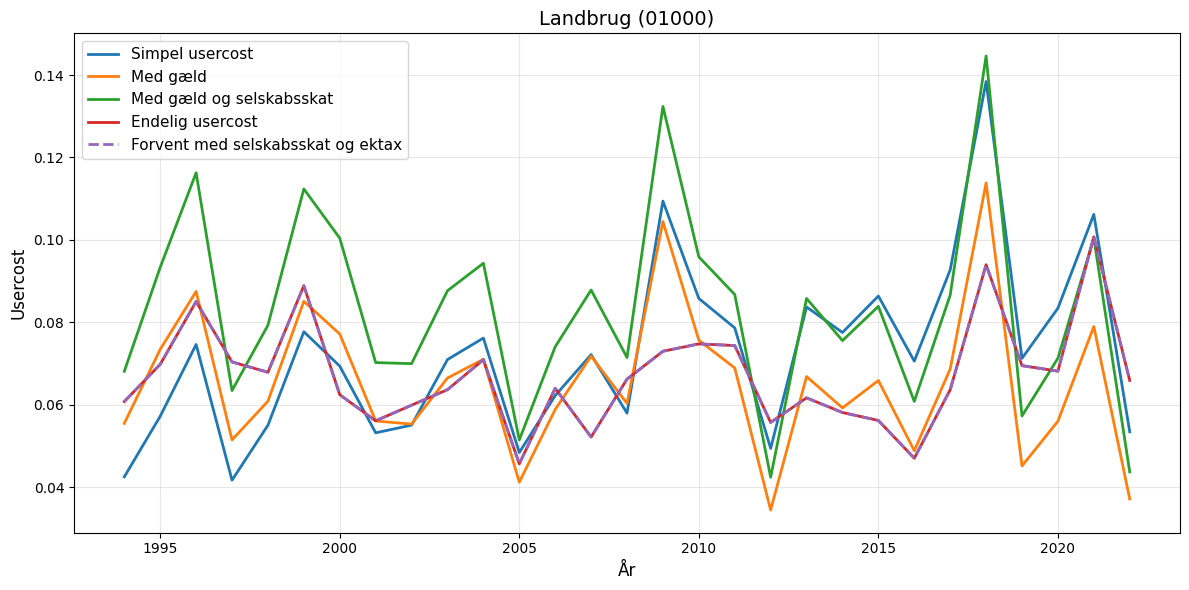

In [7]:
User_cost_landbrug=calib.P_K.loc['01000', :] 
P_K_simpel_landbrug=P_K_simpel.loc['01000', :] 
P_K_geld_landbrug=P_K_geld.loc['01000', :] 
P_K_selskab_landbrug=P_K_selskab.loc['01000', :]
P_K_selskab_ektax_landbrug=P_K_selskab_ektax.loc['01000', :]
P_K_forvent_ny_landbrug=P_K_forvent_ny.loc['01000', :]

Usercost_filtered_landbrug = User_cost_landbrug.loc[User_cost_landbrug.index >= 1994]
P_K_simpel_filtered_landbrug = P_K_simpel_landbrug.loc[P_K_simpel_landbrug.index >= 1994]
P_K_geld_filtered_landbrug = P_K_geld_landbrug.loc[P_K_geld_landbrug.index >= 1994]
P_K_selskab_filtered_landbrug = P_K_selskab_landbrug.loc[P_K_selskab_landbrug.index >= 1994]
P_K_selskab_ektax_filtered_landbrug=P_K_selskab_ektax_landbrug.loc[P_K_selskab_ektax_landbrug.index >= 1994]

plt.figure(figsize=(12, 6))

plt.plot(P_K_simpel_filtered_landbrug.index, P_K_simpel_filtered_landbrug.values, label='Simpel usercost', linewidth=2)
plt.plot(P_K_geld_filtered_landbrug.index, P_K_geld_filtered_landbrug.values, label='Med gæld', linewidth=2)
plt.plot(P_K_selskab_filtered_landbrug.index, P_K_selskab_filtered_landbrug.values, label='Med gæld og selskabsskat', linewidth=2)
plt.plot(Usercost_filtered_landbrug.index, Usercost_filtered_landbrug.values, label='Endelig usercost', linewidth=2)
plt.plot(P_K_selskab_ektax_filtered_landbrug.index, P_K_selskab_ektax_filtered_landbrug.values, label='Forvent med selskabsskat og ektax', linewidth=2, linestyle='--' )

plt.xlabel('År', fontsize=12)
plt.ylabel('Usercost', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

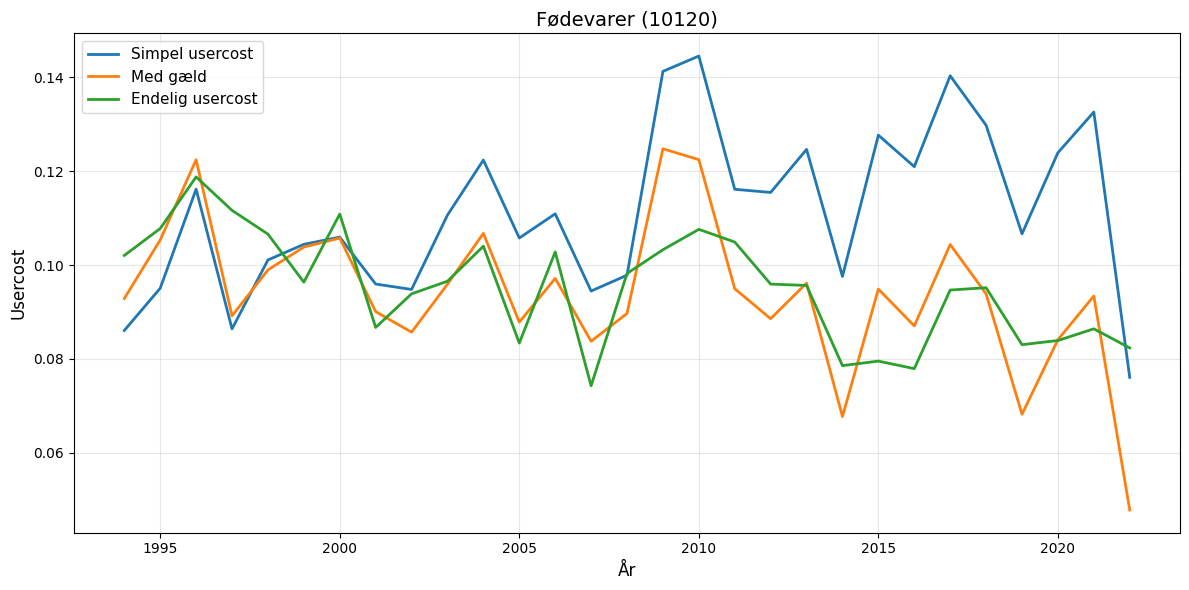

In [8]:
User_cost_fod=calib.P_K.loc['10120', :] 
P_K_simpel_fod=P_K_simpel.loc['10120', :] 
P_K_geld_fod=P_K_geld.loc['10120', :] 
P_K_selskab_fod=P_K_selskab.loc['10120', :] 

Usercost_filtered_fod = User_cost_fod.loc[User_cost_fod.index >= 1994]
P_K_simpel_filtered_fod = P_K_simpel_fod.loc[P_K_simpel_fod.index >= 1994]
P_K_geld_filtered_fod = P_K_geld_fod.loc[P_K_geld_fod.index >= 1994]
P_K_selskab_filtered_fod = P_K_selskab_fod.loc[P_K_selskab_fod.index >= 1994]

plt.figure(figsize=(12, 6))

plt.plot(P_K_simpel_filtered_fod.index, P_K_simpel_filtered_fod.values, label='Simpel usercost', linewidth=2)
plt.plot(P_K_geld_filtered_fod.index, P_K_geld_filtered_fod.values, label='Med gæld', linewidth=2)
# plt.plot(P_K_selskab_filtered_fod.index, P_K_selskab_filtered_fod.values, label='Med gæld og selskabsskat', linewidth=2)
plt.plot(Usercost_filtered_fod.index, Usercost_filtered_fod.values, label='Endelig usercost', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Usercost', fontsize=12)
plt.title('Fødevarer (10120)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

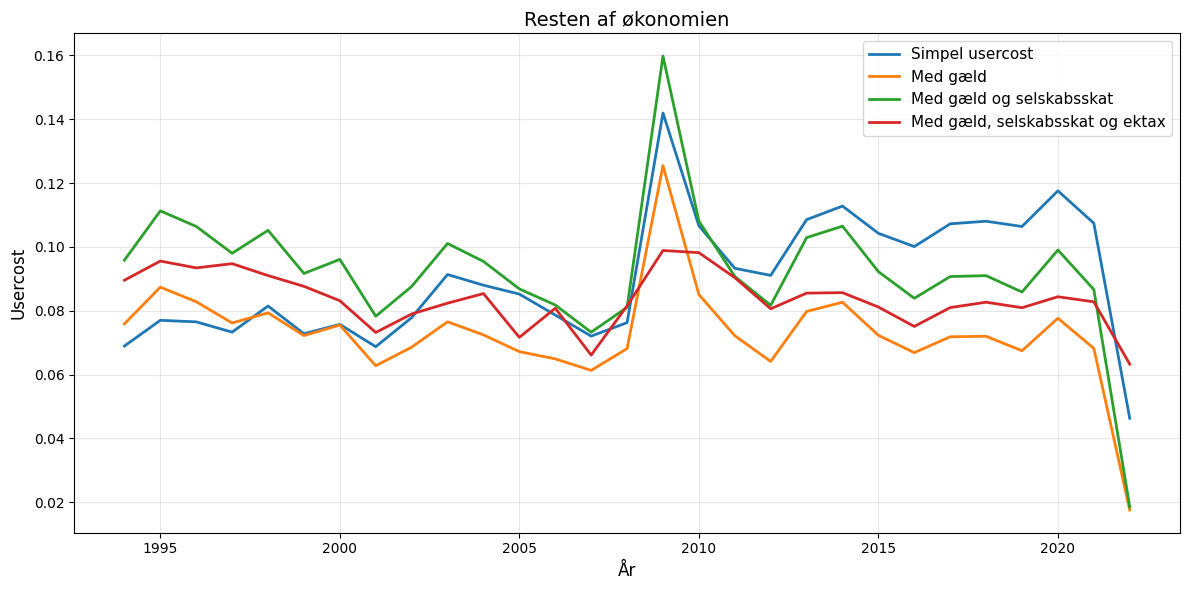

In [9]:
User_cost_rest=calib.P_K.loc['REST', :] 
P_K_simpel_rest=P_K_simpel.loc['REST', :] 
P_K_geld_rest=P_K_geld.loc['REST', :] 
P_K_selskab_rest=P_K_selskab.loc['REST', :] 

Usercost_filtered_rest = User_cost_rest.loc[User_cost_rest.index >= 1994]
P_K_simpel_filtered_rest = P_K_simpel_rest.loc[P_K_simpel_rest.index >= 1994]
P_K_geld_filtered_rest = P_K_geld_rest.loc[P_K_geld_rest.index >= 1994]
P_K_selskab_filtered_rest = P_K_selskab_rest.loc[P_K_selskab_rest.index >= 1994]

plt.figure(figsize=(12, 6))

plt.plot(P_K_simpel_filtered_rest.index, P_K_simpel_filtered_rest.values, label='Simpel usercost', linewidth=2)
plt.plot(P_K_geld_filtered_rest.index, P_K_geld_filtered_rest.values, label='Med gæld', linewidth=2)
plt.plot(P_K_selskab_filtered_rest.index, P_K_selskab_filtered_rest.values, label='Med gæld og selskabsskat', linewidth=2)
plt.plot(Usercost_filtered_rest.index, Usercost_filtered_rest.values, label='Med gæld, selskabsskat og ektax', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Usercost', fontsize=12)
plt.title('Resten af økonomien', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# User_cost_ny=calib.P_K.loc['01000', :] 
# Usercost_gammel=P_K.loc['01000', :] 
# # Usercost_prev=P_K_dynamisk.loc['01000', :]
# Usercost_forvent=P_K_forvent.loc['01000', :]

# User_cost_filtered = Usercost_gammel.loc[Usercost_gammel.index >= 1994]
# Usercost_ny_filtered = User_cost_ny.loc[User_cost_ny.index >= 1994]
# # Usercost_prev_filtered = Usercost_prev.loc[Usercost_prev.index >= 1994]
# Usercost_forvent_filtered = Usercost_forvent.loc[Usercost_forvent.index >= 1997]
# plt.figure(figsize=(12, 6))
# plt.plot(User_cost_filtered.index, User_cost_filtered.values, label='Oprindelig usercost', linewidth=2)
# plt.plot(Usercost_ny_filtered.index, Usercost_ny_filtered.values, label='Ifølge ny model', linewidth=2)
# # plt.plot(Usercost_prev_filtered.index, Usercost_prev_filtered.values, label='Dynamisk usercost', linewidth=2)
# plt.plot(Usercost_forvent_filtered.index, Usercost_forvent_filtered.values, label='Usercost m 3 år glidende gennemsnit', linewidth=2)

# plt.xlabel('År', fontsize=12)
# plt.ylabel('Usercost', fontsize=12)
# plt.title('Landbrug (01000)', fontsize=14)
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# Jordresidual

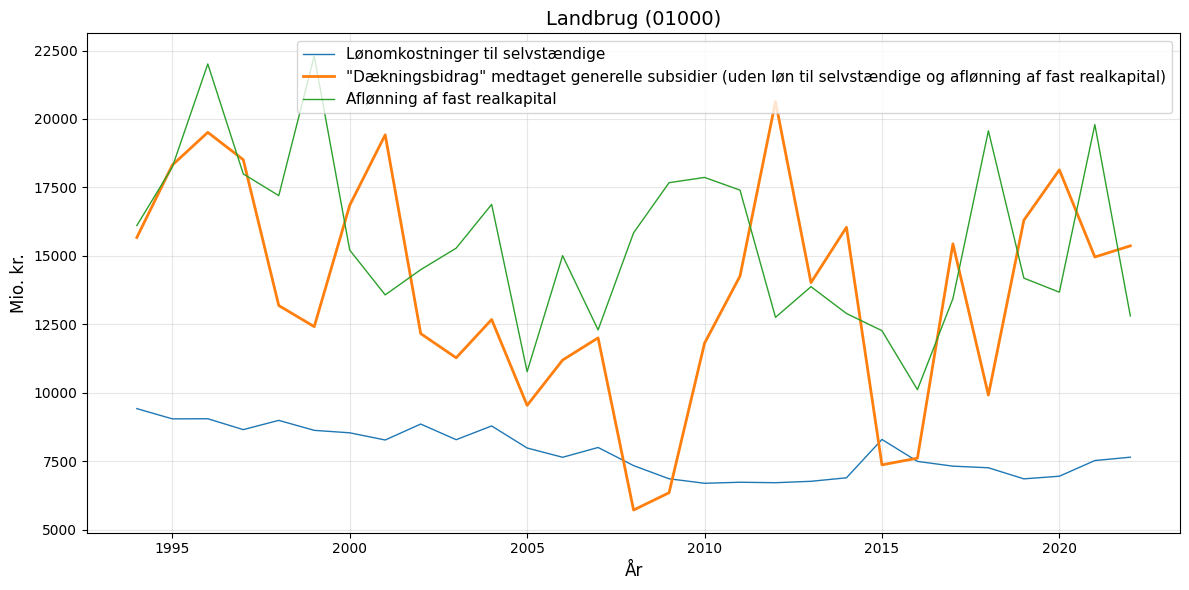

ANVENDELSE  TID 
01000       1966         NaN
            1967         NaN
            1968         NaN
            1969         NaN
            1970         NaN
                      ...   
REST        2020    0.084380
            2021    0.082776
            2022    0.063258
            2023         NaN
            2024         NaN
Length: 177, dtype: float64

In [11]:
calib.Res.loc[ slice(1994, 2022)]
Res = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] -calib.subs_adj.loc['01000',:]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L['Xt'].loc['01000', :]
       - calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :])
Res.loc[slice(1994, 2022)]

DB = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :])
DB_med_subs= DB-calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K_plus_L=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :] + L_selv
K=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :]
# calib.P_MxM_tot.loc['01000', :]
# calib.P_K.loc['01000', :]/2 

DB_filtered = DB.loc[DB.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_plus_L_filtered = K_plus_L.loc[K_plus_L.index >= 1994]
DB_med_subs_filtered = DB_med_subs.loc[DB_med_subs.index >= 1994]
K_filtered = K.loc[K.index >= 1994]
Res_filtered = Res.loc[Res.index >= 1994]

plt.figure(figsize=(12, 6))
# plt.plot(DB_filtered.index, DB_filtered.values, label='DB', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=1)
# plt.plot(K_plus_L_filtered.index, K_plus_L_filtered.values, label='Aflønning af fast realkapital + lønomkostninger til selvstændige', linewidth=2)
plt.plot(DB_med_subs_filtered.index, DB_med_subs_filtered.values, label='"Dækningsbidrag" medtaget generelle subsidier (uden løn til selvstændige og aflønning af fast realkapital)', linewidth=2)
plt.plot(K_filtered.index, K_filtered.values, label='Aflønning af fast realkapital', linewidth=1)
# plt.plot(Res_filtered.index, Res_filtered.values, label='Jordresidual', linewidth=2)
plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
calib.P_K

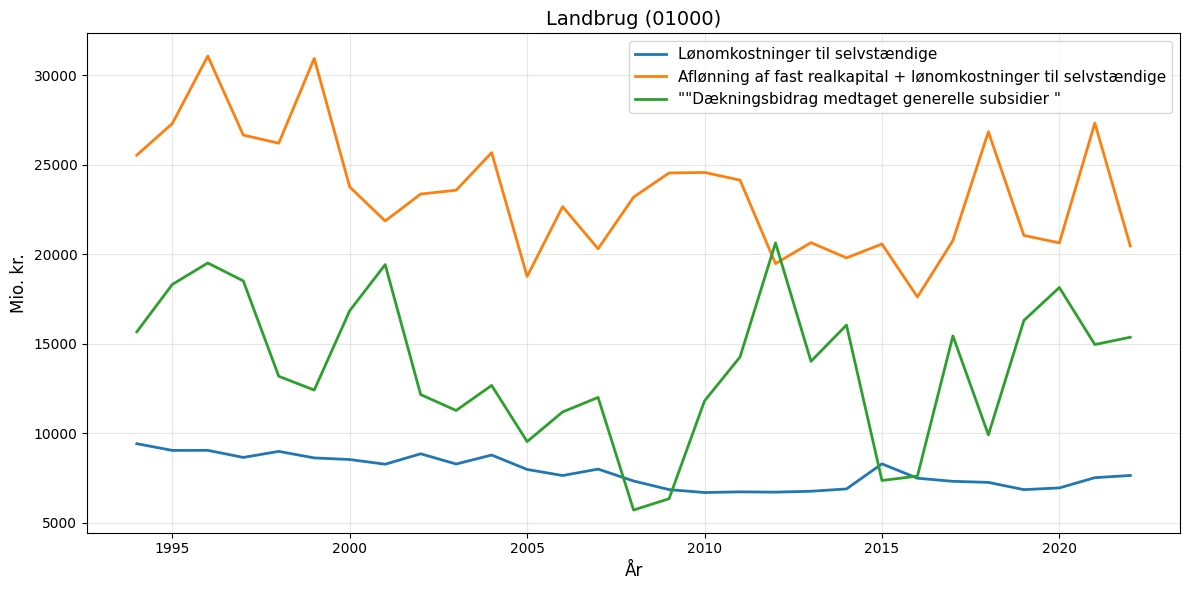

In [12]:
calib.Res.loc[ slice(1994, 2022)]
Res = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] -calib.subs_adj.loc['01000',:]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L['Xt'].loc['01000', :]
       - calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :])
Res.loc[slice(1994, 2022)]

DB = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :])
DB_med_subs= DB-calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K_plus_L=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :] + L_selv
K=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :]
# calib.P_MxM_tot.loc['01000', :]
# calib.P_K.loc['01000', :]/2 

DB_filtered = DB.loc[DB.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_plus_L_filtered = K_plus_L.loc[K_plus_L.index >= 1994]
DB_med_subs_filtered = DB_med_subs.loc[DB_med_subs.index >= 1994]
K_filtered = K.loc[K.index >= 1994]

plt.figure(figsize=(12, 6))
# plt.plot(DB_filtered.index, DB_filtered.values, label='DB', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=2)
plt.plot(K_plus_L_filtered.index, K_plus_L_filtered.values, label='Aflønning af fast realkapital + lønomkostninger til selvstændige', linewidth=2)
plt.plot(DB_med_subs_filtered.index, DB_med_subs_filtered.values, label='""Dækningsbidrag medtaget generelle subsidier "', linewidth=2)
# plt.plot(K_filtered.index, K_filtered.values, label='K', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

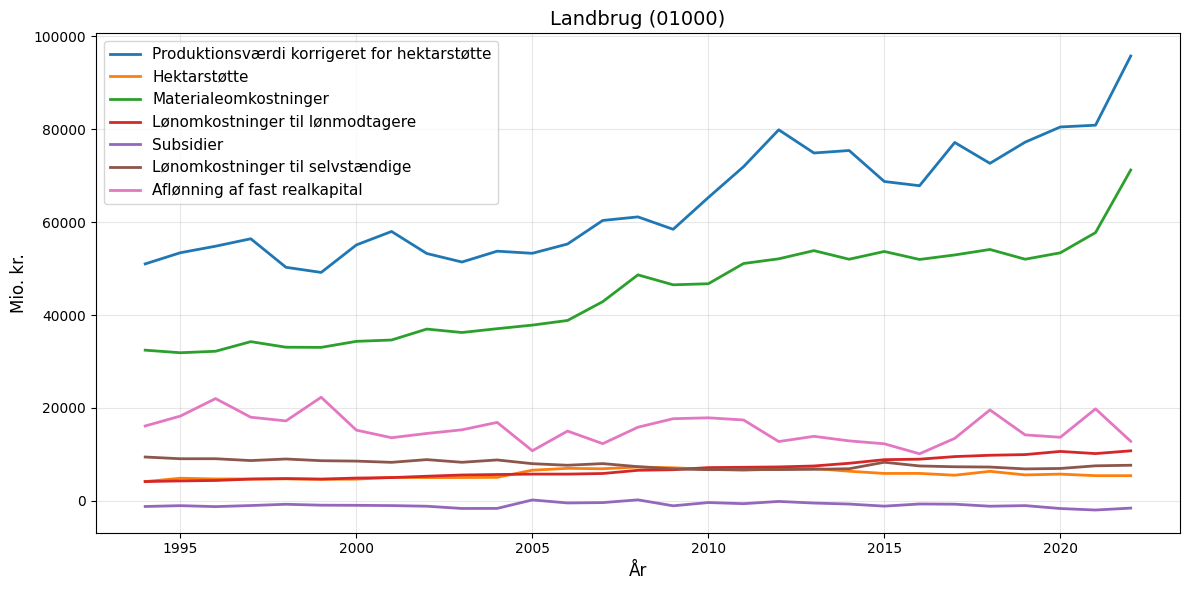

In [13]:
Produktionsværdi = df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] - calib.hektarstotte_adjusted
Hektarstot = df.hektarstotte['INDHOLD']
Materialer =  calib.P_MxM_tot.loc['01000', :]
Lon_til_lonmodtager = df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :]
Subsidier= calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :]

Produktionsværdi_filtered = Produktionsværdi.loc[Produktionsværdi.index >= 1994]
Hektarstot_filtered = Hektarstot.loc[Hektarstot.index >= 1994]
Materialer_filtered = Materialer.loc[Materialer.index >= 1994]
Lon_til_lonmodtager_filtered = Lon_til_lonmodtager.loc[Lon_til_lonmodtager.index >= 1994]
Subsidier_filtered = Subsidier.loc[Subsidier.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_filtered = K.loc[K.index >= 1994]

plt.figure(figsize=(12, 6))
plt.plot(Produktionsværdi_filtered.index, Produktionsværdi_filtered.values, label='Produktionsværdi korrigeret for hektarstøtte', linewidth=2)
plt.plot(Hektarstot_filtered.index, Hektarstot_filtered.values, label='Hektarstøtte', linewidth=2)
plt.plot(Materialer_filtered.index, Materialer_filtered.values, label='Materialeomkostninger', linewidth=2)
plt.plot(Lon_til_lonmodtager_filtered.index, Lon_til_lonmodtager_filtered.values, label='Lønomkostninger til lønmodtagere', linewidth=2)
plt.plot(Subsidier_filtered.index, Subsidier_filtered.values, label='Subsidier', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=2)
plt.plot(K_filtered.index, K_filtered.values, label='Aflønning af fast realkapital', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
with pd.ExcelWriter("modeldata_ra.xlsx") as writer:
    df.Y.unstack('TID').to_excel(writer, sheet_name="Y")
    df.Mtot.unstack('TID').to_excel(writer, sheet_name="M_tot")
    # df.JKL.unstack('TID').to_excel(writer, sheet_name="JKL")
    df.KL.unstack('TID').to_excel(writer, sheet_name="KL")
    df.M_D.unstack('TID').to_excel(writer, sheet_name="M_D")
    df.M_F.unstack('TID').to_excel(writer, sheet_name="M_F")
    df.L.unstack('TID').to_excel(writer, sheet_name="L")
    df.J.unstack('TID').to_excel(writer, sheet_name="J")
    df.K.unstack('TID').to_excel(writer, sheet_name="K")
    df.MDtot.unstack('TID').to_excel(writer, sheet_name="MDtot")
    df.MFtot.unstack('TID').to_excel(writer, sheet_name="MFtot")
    
    df.P.unstack('TID').to_excel(writer, sheet_name="P")
    df.P_Mtot.unstack('TID').to_excel(writer, sheet_name="P_Mtot")
    # df.P_JKL.unstack('TID').to_excel(writer, sheet_name="P_JKL")
    df.P_KL.unstack('TID').to_excel(writer, sheet_name="P_KL")
    df.P_D.unstack('TID').to_excel(writer, sheet_name="P_D")
    df.P_F.unstack('TID').to_excel(writer, sheet_name="P_F")
    df.w.unstack('TID').to_excel(writer, sheet_name="w")
    calib.P_J.to_frame().T.to_excel(writer, sheet_name="P_Jord")
    calib.P_K.unstack('TID').to_excel(writer, sheet_name="P_K")
    df.P_MDtot.unstack('TID').to_excel(writer, sheet_name="P_MDtot")
    df.P_MFtot.unstack('TID').to_excel(writer, sheet_name="P_MFtot")

In [15]:
# Laver et loop over alle variable hvor jeg tager Y og dividerer med den givne variabel
#definerer de variable det drejer sig om
variables = ['Mtot','K', 'L', 'J']
for variable in variables:
    setattr(df, f'{variable}_Y', getattr(df, variable)/df.Y )


from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Angiv PDF-filnavn
pdf_filename = "Mængder_Y.pdf"

with PdfPages(pdf_filename) as pdf:
# laver et plot over det nye variable over tid - hver branche som sin egen linje
    for variable in variables:
        theta_var = getattr(df, f'{variable}_Y')
        
        if 'ANVENDELSE' in theta_var.index.names:
            theta_wide = theta_var.unstack('ANVENDELSE').sort_index()
    
            # starter i 1993
            theta_wide = theta_wide.loc[theta_wide.index.get_level_values('TID') >= 1993]
    
            years = theta_wide.index.get_level_values('TID') if 'TID' in theta_wide.index.names else theta_wide.index
            
            plt.figure(figsize=(10, 5))
            for branche in theta_wide.columns:
                plt.plot(years, theta_wide[branche], label=branche)
    
            plt.xlabel("År")
            plt.ylabel(f"({variable}/Y)")
            plt.title(f"Mængder {variable}/Y over tid fordelt på branche")
            plt.legend(title="Branche")
            plt.grid(True, alpha=0.3)
            plt.ylim(bottom=0)
            plt.tight_layout()
            pdf.savefig()  # Gem figuren i PDF
            plt.close()


C:\Users\b431385\AppData\Local\Temp\ipykernel_14784\2176609190.py:29: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(years, theta_wide[branche], label=branche)


In [16]:
calib.P_K = calib.P_K.to_frame(name='Pt')

In [17]:
variables = ['P_Mtot', 'w', 'P_K']

for variable in variables:

    if hasattr(df, variable):
        var_data = getattr(df, variable)

    elif hasattr(calib, variable):
        var_data = getattr(calib, variable)

    setattr(df, f'{variable}_P', var_data/df.P )

# Angiv PDF-filnavn
pdf_filename = "Priser_Y.pdf"

with PdfPages(pdf_filename) as pdf:
# laver et plot over det nye variable over tid - hver branche som sin egen linje
    for variable in variables:
        theta_var = getattr(df, f'{variable}_P')

        if 'ANVENDELSE' in theta_var.index.names:
            theta_wide = theta_var.unstack('ANVENDELSE').sort_index()

            # starter i 1993
            theta_wide = theta_wide.loc[theta_wide.index.get_level_values('TID') >= 1993]

            years = theta_wide.index.get_level_values('TID') if 'TID' in theta_wide.index.names else theta_wide.index

            plt.figure(figsize=(10, 5))
            for branche in theta_wide.columns:
                plt.plot(years, theta_wide[branche], label=branche)

            plt.xlabel("År")
            plt.ylabel(f"({variable}/Y)")
            plt.title(f"Priser {variable}/Y over tid fordelt på branche")
            plt.legend(title="Branche")
            plt.grid(True, alpha=0.3)
            plt.ylim(bottom=0)
            plt.tight_layout()
            pdf.savefig()  # Gem figuren i PDF
            plt.close()

C:\Users\b431385\AppData\Local\Temp\ipykernel_14784\1109220284.py:31: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(years, theta_wide[branche], label=branche)


In [18]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

brancher = calib.theta_Y_KL_indeks.index.get_level_values('ANVENDELSE').unique()
tilgang_labels = {'01000': 'Landbrugssektor', '10120': 'Fødevaresektor', 'REST': 'Resten af økonomien'}

pdf_filename = "produktivitetsparametre_alle_brancher_ey0_ekl0.pdf"

with PdfPages(pdf_filename) as pdf:
    for branche in brancher:

        # --- Figur 1: Y-niveau ---
        d = calib.theta_Y_KL_indeks.loc[branche, slice(1994, 2022)]
        p = calib.theta_Y_Mtot_indeks.loc[branche, slice(1994, 2022)]
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        plt.plot(years, d.values, label=r'$\theta^{Y,KL}_{it}$  (Kapital + Arbejde)')
        plt.plot(years, p.values, label=r'$\theta^{Y,M}_{it}$  (Materialer)')
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(f"Produktivitetsparametre – Branche {branche}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 2: KL-niveau ---
        d = calib.theta_KL_K_indeks.loc[branche, slice(1994, 2022)]
        p = calib.theta_KL_L_indeks.loc[branche, slice(1994, 2022)]
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        plt.plot(years, d.values, label=r'$\theta^{KL,K}_{it}$  (Kapital)')
        plt.plot(years, p.values, label=r'$\theta^{KL,L}_{it}$  (Arbejde)')
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(f"KL-produktivitetsparametre – Branche {branche}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 3: Mtot-M niveau ---
        d = calib.theta_Mtot_M_indeks.loc[(branche, slice(None), slice(1994, 2022))]
        d_wide = d.unstack('TILGANG2').sort_index()
        years = d_wide.index.get_level_values('TID')

        plt.figure(figsize=(10,5))
        for col in d_wide.columns:
            plt.plot(years, d_wide[col], label=col)
        plt.xlabel("År")
        plt.ylabel("Indeks (1994=1)")
        plt.title(rf'$\theta^{{Mtot,M}}_{{it}}$ Materiale-CES – Branche {branche}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(bottom=0)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

        # --- Figur 4-6: MD/MF per tilgang ---
        for tilgang, label in tilgang_labels.items():
            try:
                d = calib.theta_MD_indeks.loc[(branche, tilgang, slice(1994, 2022))]
                p = calib.theta_MF_indeks.loc[(branche, tilgang, slice(1994, 2022))]
                years = d.index.get_level_values('TID')

                plt.figure(figsize=(10,5))
                plt.plot(years, d.values, label=r'$\theta^{MD}_{it}$ Danske materialer')
                plt.plot(years, p.values, label=r'$\theta^{MF}_{it}$ Importerede materialer')
                plt.xlabel("År")
                plt.ylabel("Indeks (1994=1)")
                plt.title(f"Materiale-CES – {label} – Branche {branche}")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.ylim(bottom=0)
                plt.tight_layout()
                pdf.savefig()
                plt.close()
            except KeyError:
                plt.close()
                continue

        # --- Figur 7: JKL (kun landbrug) ---
        if branche == '01000':
            try:
                d = calib.theta_JKL_J_indeks.loc['01000', 1994:2022]
                p = calib.theta_JKL_KL_indeks.loc['01000', 1994:2022]
                years = d.index.get_level_values('TID')
                
                plt.figure(figsize=(10,5))
                plt.plot(years, d.values, label=r'$\theta^{JKL,J}_{it}$  (Jord)')
                plt.plot(years, p.values, label=r'$\theta^{JKL,KL}_{it}$  (KL-aggregat)')
                plt.xlabel("År")
                plt.ylabel("Indeks (1994=1)")
                plt.title("JKL-produktivitetsparametre – Landbrug (01000)")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.ylim(bottom=0)
                plt.tight_layout()
                pdf.savefig()
                plt.close()
            except KeyError:
                plt.close()

print(f"Alle figurer er gemt i {pdf_filename}")

Alle figurer er gemt i produktivitetsparametre_alle_brancher_ey0_ekl0.pdf


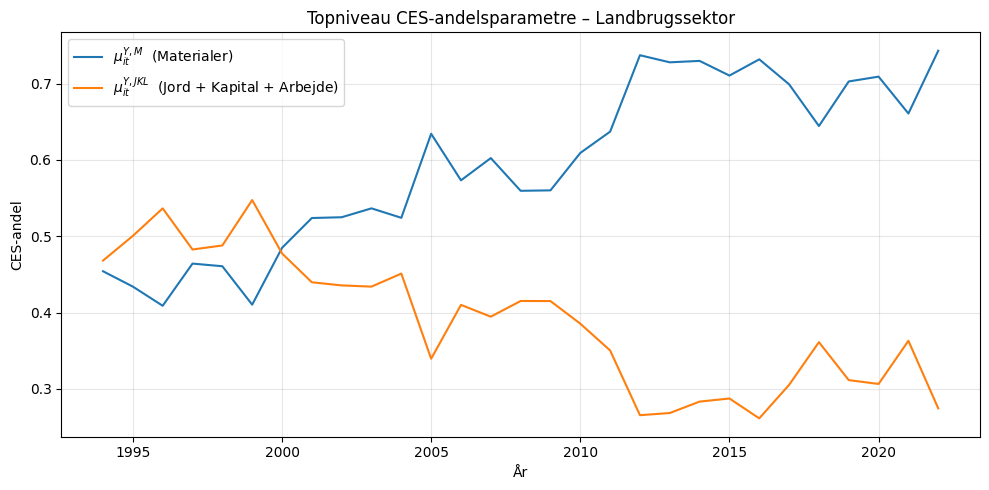

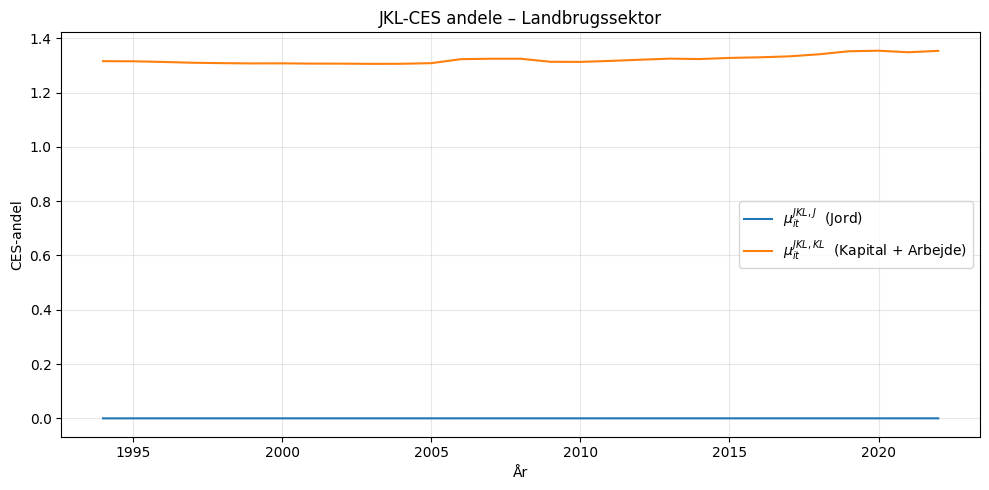

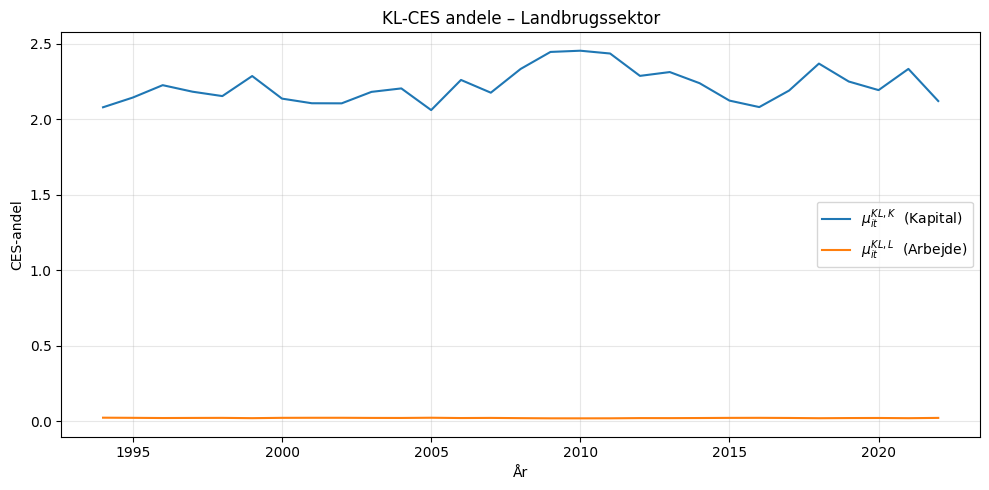

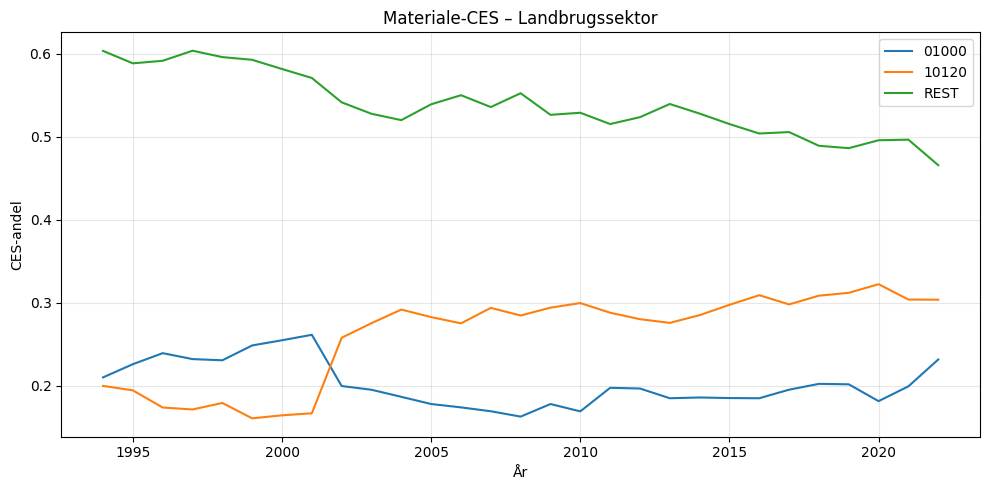

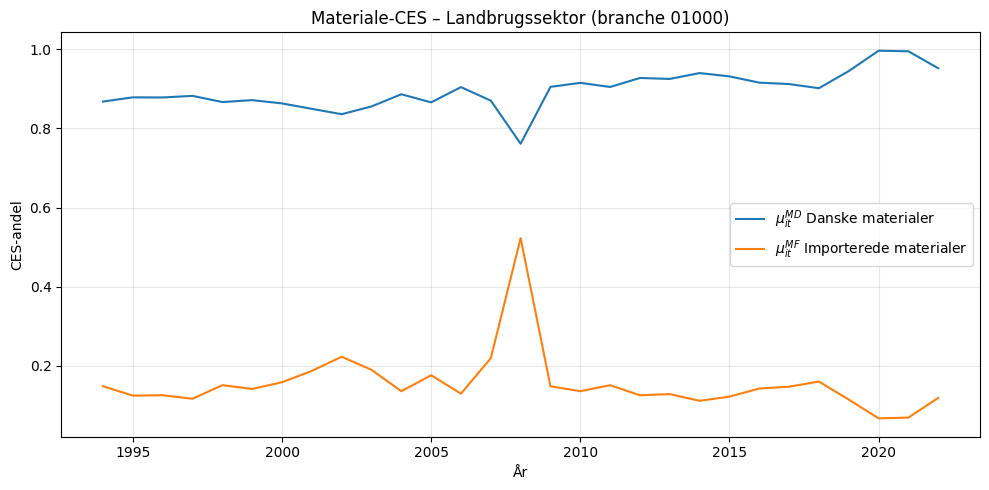

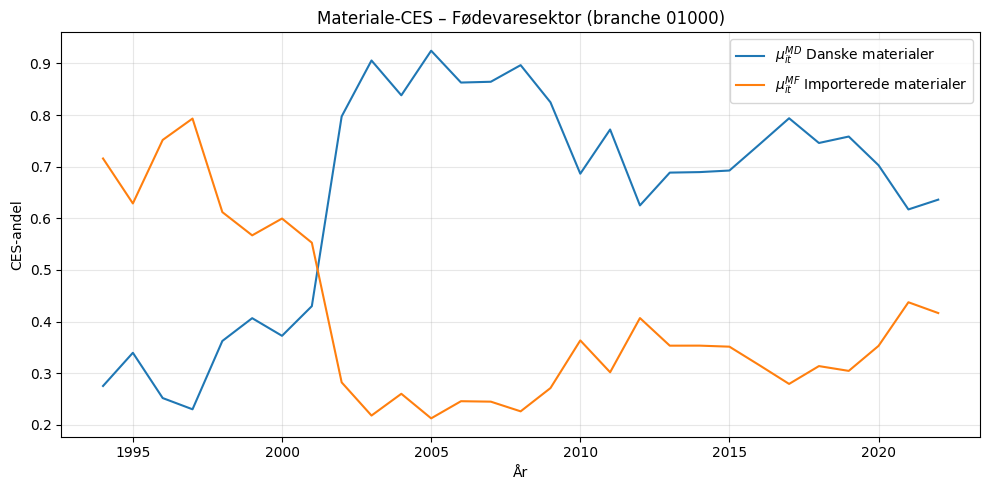

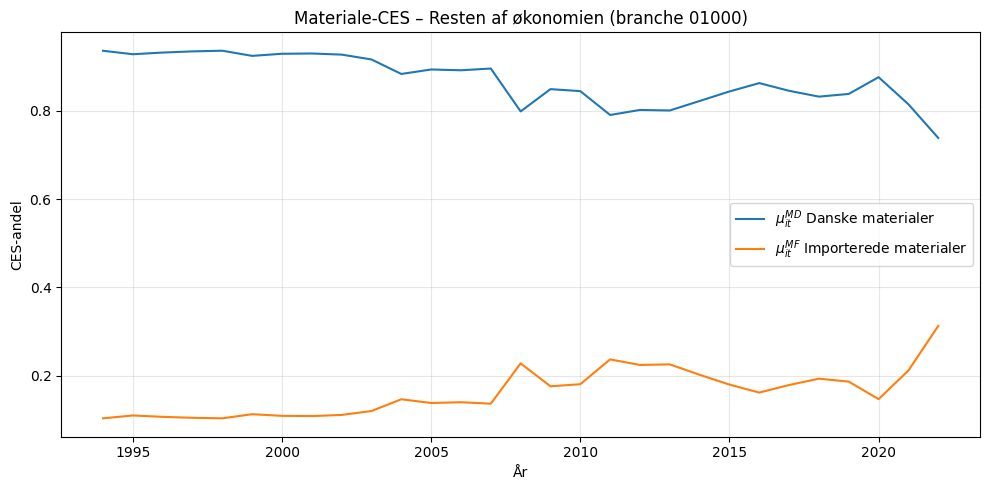

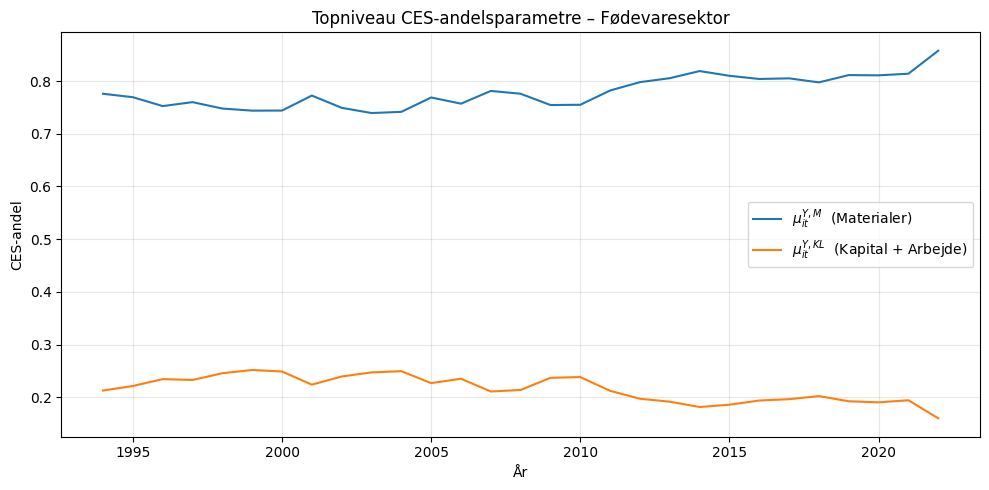

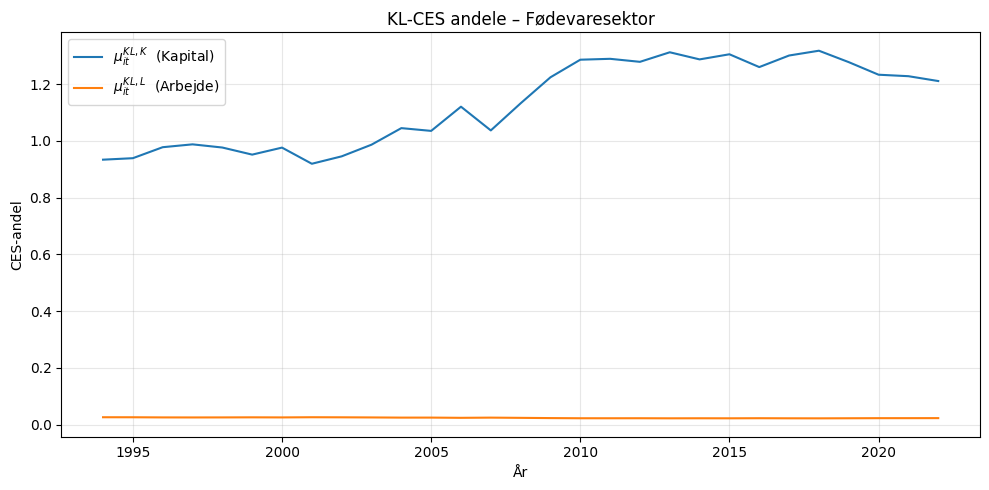

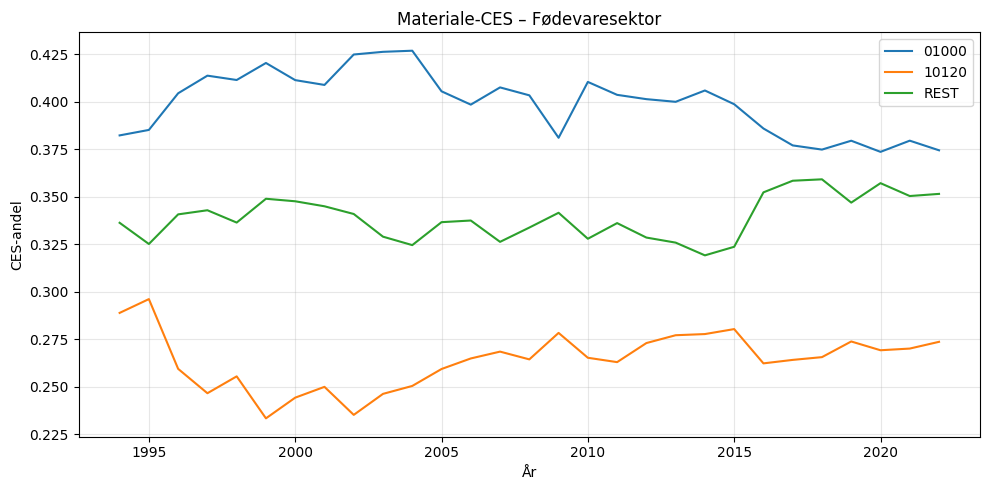

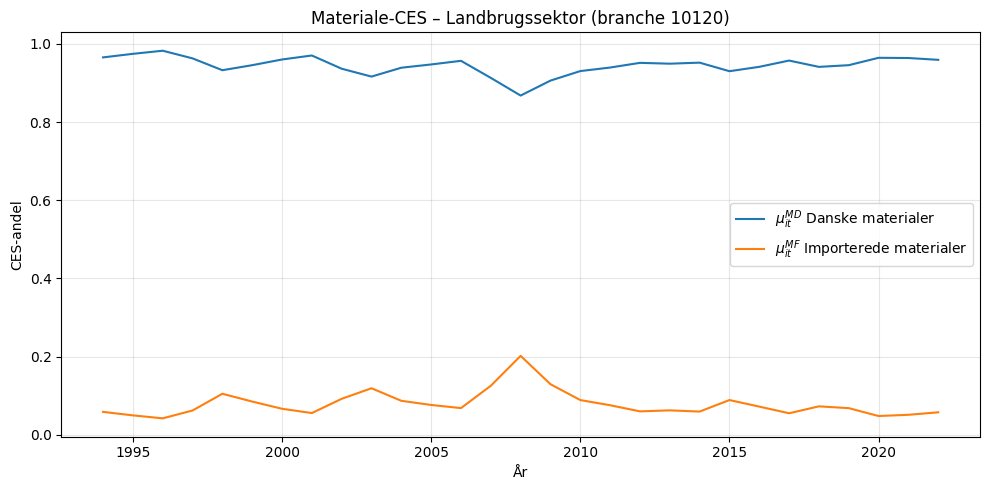

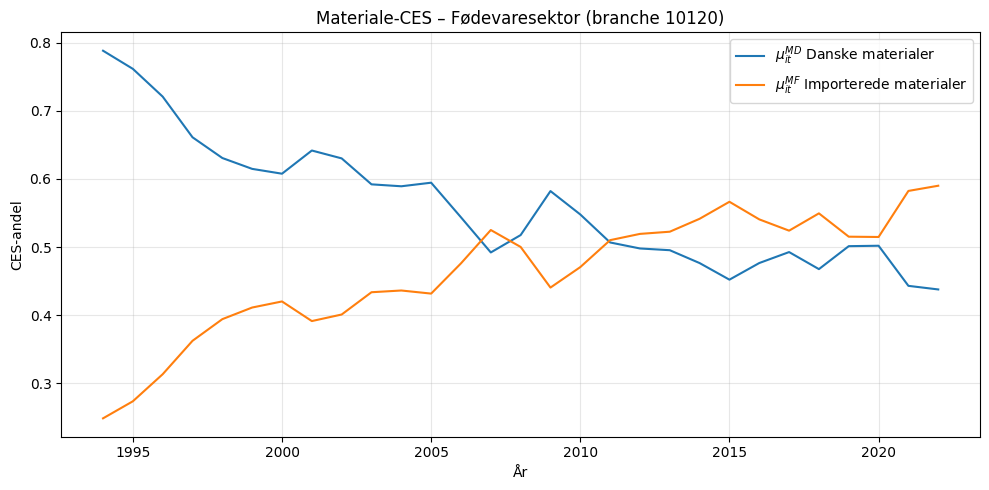

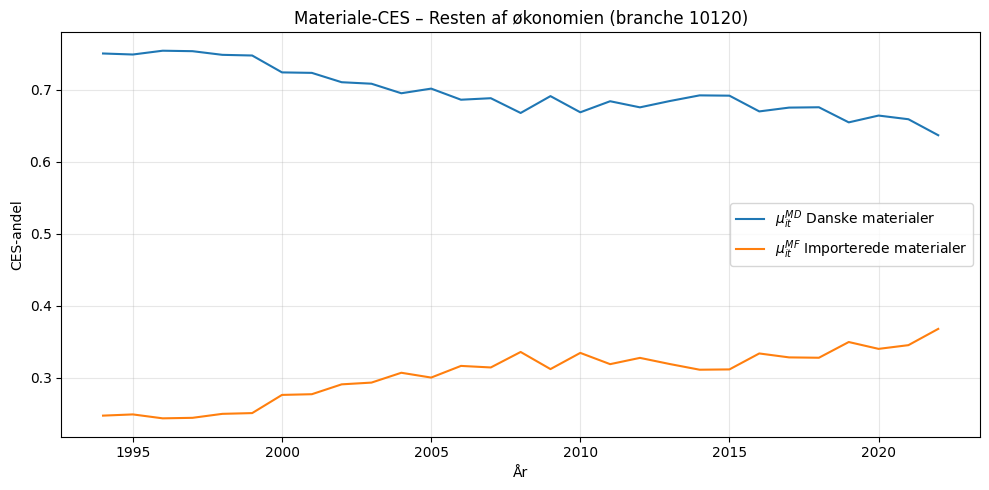

In [19]:
def plot_ces_andele(calib, branche, har_JKL=False):
    tilgang_labels = {'01000': 'Landbrugssektor', '10120': 'Fødevaresektor', 'REST': 'Resten af økonomien'}
    branche_navn = tilgang_labels.get(branche, branche)

    # Figur 1: Topniveau
    d = calib.mu_Y_Mtot.loc[branche, slice(1994, 2022)].copy()
    if har_JKL:
        p = calib.mu_Y_JKL.loc[branche, slice(1994, 2022)].copy()
        kl_label = r'$\mu^{Y,JKL}_{it}$  (Jord + Kapital + Arbejde)'
    else:
        p = calib.mu_Y_KL.loc[branche, slice(1994, 2022)].copy()
        kl_label = r'$\mu^{Y,KL}_{it}$  (Kapital + Arbejde)'
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10, 5))
    plt.plot(years, d.values, label=r'$\mu^{Y,M}_{it}$  (Materialer)')
    plt.plot(years, p.values, label=kl_label)
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Topniveau CES-andelsparametre – {branche_navn}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figur 2: JKL (kun landbrug)
    if har_JKL:
        d = calib.mu_JKL_J.loc[branche, slice(1994, 2022)]
        p = calib.mu_JKL_KL.loc[branche, slice(1994, 2022)]
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10, 5))
        plt.plot(years, d.values, label=r'$\mu^{JKL,J}_{it}$  (Jord)')
        plt.plot(years, p.values, label=r'$\mu^{JKL,KL}_{it}$  (Kapital + Arbejde)')
        plt.xlabel("År")
        plt.ylabel("CES-andel")
        plt.title(f"JKL-CES andele – {branche_navn}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Figur 3: KL-niveau
    d = calib.mu_KL_K.loc[branche, slice(1994, 2022)]
    p = calib.mu_KL_L.loc[branche, slice(1994, 2022)]
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10, 5))
    plt.plot(years, d.values, label=r'$\mu^{KL,K}_{it}$  (Kapital)')
    plt.plot(years, p.values, label=r'$\mu^{KL,L}_{it}$  (Arbejde)')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"KL-CES andele – {branche_navn}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figur 4: Materiale-CES
    d = calib.mu_Mtot_M.loc[(branche, slice(None), slice(1994, 2022))].copy()
    d_wide = d.unstack('TILGANG2').sort_index()
    years = d_wide.index.get_level_values('TID')

    plt.figure(figsize=(10, 5))
    for col in d_wide.columns:
        plt.plot(years, d_wide[col], label=col)
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – {branche_navn}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figur 5-7: MD/MF per tilgang
    for tilgang, label in tilgang_labels.items():
        d = calib.mu_MD.loc[(branche, tilgang, slice(1994, 2022))].copy()
        p = calib.mu_MF.loc[(branche, tilgang, slice(1994, 2022))].copy()
        years = d.index.get_level_values('TID')

        plt.figure(figsize=(10, 5))
        plt.plot(years, d.values, label=r'$\mu^{MD}_{it}$ Danske materialer')
        plt.plot(years, p.values, label=r'$\mu^{MF}_{it}$ Importerede materialer')
        plt.xlabel("År")
        plt.ylabel("CES-andel")
        plt.title(f"Materiale-CES – {label} (branche {branche})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# Kald for begge brancher
plot_ces_andele(calib, '01000', har_JKL=True)
plot_ces_andele(calib, '10120', har_JKL=False)

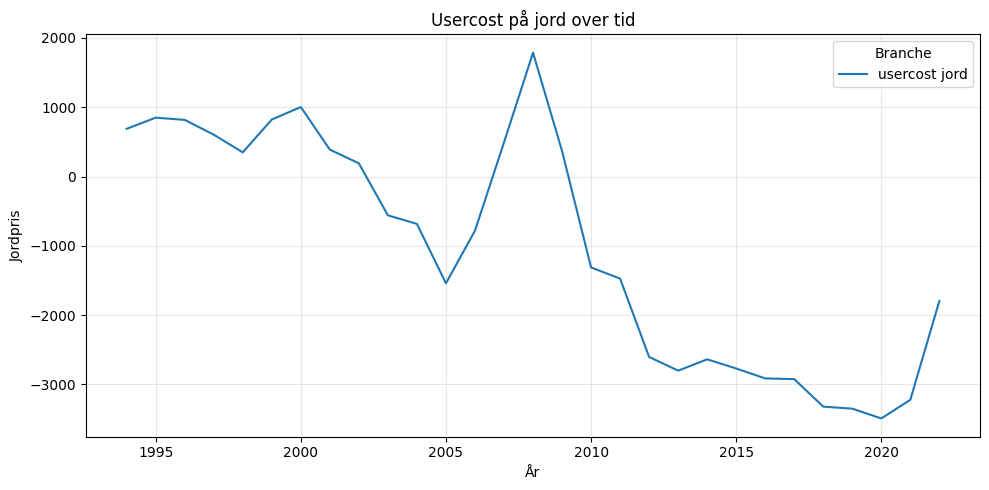

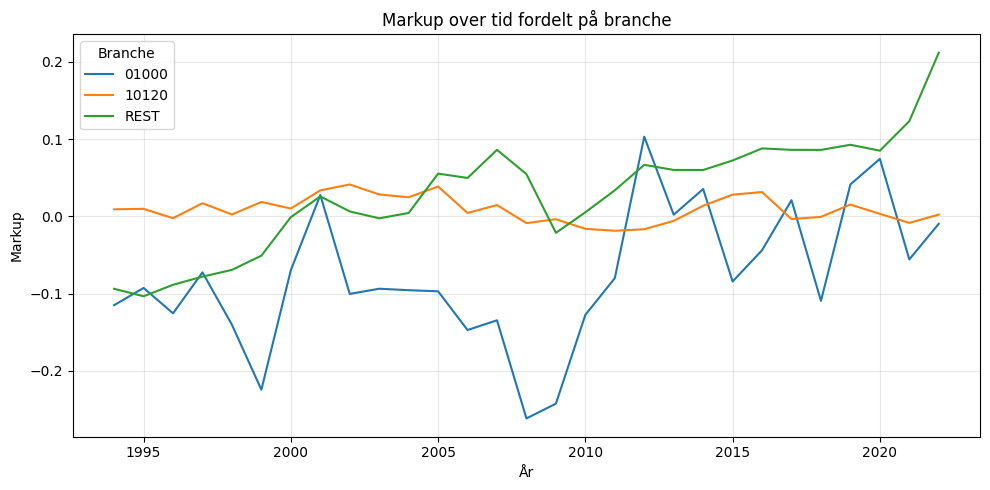

TID
1994     482.185256
1995     525.782704
1996     569.418850
1997     322.832804
1998      63.364022
1999     467.469557
2000     700.391178
2001     -23.869047
2002    -249.920740
2003   -1028.685352
2004   -1129.323106
2005   -1921.993726
2006   -1160.931739
2007      97.732600
2008    1383.027330
2009     -56.973319
2010   -1764.942857
2011   -1755.187901
2012   -2899.339366
2013   -3118.614323
2014   -2962.334602
2015   -3117.848852
2016   -3272.338457
2017   -3285.430191
2018   -3686.899673
2019   -3718.519329
2020   -3865.624681
2021   -3596.714020
2022   -2175.383778
dtype: float64

In [20]:
# Kun 1993 og frem
d = calib.P_J.loc[(slice(1994, 2022))].copy()
P_J=((((1+calib.r.loc['01000'])*calib.P_Jord_prev['Pt']-calib.P_Jord_prev['Pt']*calib.inf_J['Pt'])
    -((calib.r.loc['01000']-df.rBonds['Pt'].loc['01000']*(1-df.tCorp['Pt'].loc['01000']))*0.6*calib.P_Jord_prev['Pt']))
    /(1-df.tCorp['Pt'].loc['01000'])
    -calib.s_hektar).loc[(slice(1994, 2022))].copy()
p=df.P_Jord['Pt'].loc[(slice(1994, 2022))].copy()
# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d, label='usercost jord')
# plt.plot(d.index, p, label='Jordpris ')
plt.xlabel("År")
plt.ylabel("Jordpris")
plt.title("Usercost på jord over tid")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Kun 1993 og frem
d = calib.markup.loc[(slice(None), slice(1994, 2022))].copy()
# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)
plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
P_J

# Datatjeks